# Example-12: Operations with window

In [1]:
# Import

import epics
import numpy
import torch

import sys
sys.path.append('..')

from harmonica.util import pv_make
from harmonica.window import Window
from harmonica.data import Data

import matplotlib.pyplot as plt
from time import sleep

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(1024, 'cosine_window', 5.0)
Data(1, Window(1024, 'cosine_window', 5.0))
tensor([1.000668503033e+00], dtype=torch.float64)
tensor([1.000000000000e+00], dtype=torch.float64)
tensor([0.], dtype=torch.float64)


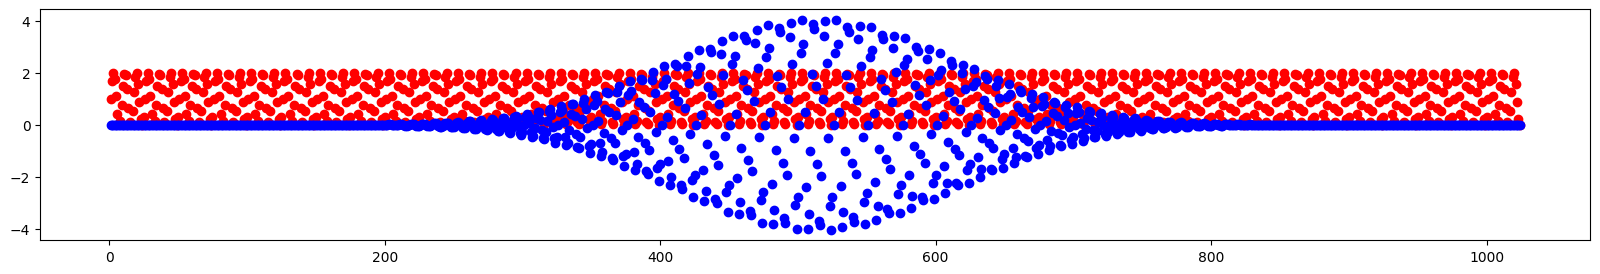

In [3]:
# tbt.window_mean           -- return window weighted mean
# tbt.window_remove_mean    -- copy data to work with removed window weighted mean
# tbt.window_apply          -- apply window to work

# Set window

w = Window.from_cosine(1024, 5.0, dtype=dtype, device=device)
print(w)

# Set tbt

d = Data.from_data(w, torch.stack([1.0 + torch.sin(2.0*numpy.pi*0.12*torch.linspace(0, 1024-1, 1024, dtype=dtype, device=device))]))
print(d)

# Compute mean values

print(torch.mean(d.data, -1))
print(*d.window_mean())

# Remove mean

d.window_remove_mean()
print(*torch.round(d.window_mean()))

# Apply window (change work)

d.window_apply()

# Plot 

t = torch.linspace(1, 1024, 1024, dtype=dtype, device=device)
plt.figure(figsize=(20, 3))
plt.scatter(t.cpu().numpy(), d.data[0].cpu().numpy(), color='red')
plt.scatter(t.cpu().numpy(), d.work[0].cpu().numpy(), color='blue')
plt.show()

# Clean

del w
del d
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()